In [7]:
#!/usr/bin/env python3
"""
Plot GPU memory usage from CSV with columns:
timestamp,gpu_index,memory_used_MiB,memory_total_MiB

Examples:
  python plot_gpu_mem.py gpu_mem.csv
  python plot_gpu_mem.py gpu_mem.csv --outdir plots --resample 30S --rolling 5
"""

import argparse
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def load_data(csv_path: Path) -> pd.DataFrame:
    # skipinitialspace handles " 26203" etc.
    df = pd.read_csv(
        csv_path,
        parse_dates=["timestamp"],
        skipinitialspace=True,
        dtype={"gpu_index": "int64"},
    )
    # Ensure numeric types (coerce bad rows to NaN, then drop)
    for col in ["memory_used_MiB", "memory_total_MiB"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["timestamp", "gpu_index", "memory_used_MiB", "memory_total_MiB"])
    df = df.sort_values(["timestamp", "gpu_index"]).reset_index(drop=True)
    # Percentage per-row; handles any varying totals
    df["usage_pct"] = (df["memory_used_MiB"] / df["memory_total_MiB"]) * 100.0
    return df


def maybe_resample_and_smooth(df, resample: str | None, rolling: int | None):
    def _process(g):
        # keep gpu_index as a normal column; only index by time
        g = g.set_index("timestamp")
        if resample:
            g = g.resample(resample).median()
        if rolling and rolling > 1:
            cols = ["memory_used_MiB", "memory_total_MiB", "usage_pct"]
            g[cols] = g[cols].rolling(rolling, min_periods=1).mean()
        return g.reset_index()

    # Crucial changes: group_keys=False and no reset_index(level=0) afterwards
    out = (
        df.groupby("gpu_index", group_keys=False, sort=True)
          .apply(_process)
          .sort_values(["timestamp", "gpu_index"])
          .reset_index(drop=True)
    )
    return out



def plot_per_gpu(df: pd.DataFrame, outdir: Path) -> None:
    gpus = df["gpu_index"].unique()
    for gpu in gpus:
        g = df[df["gpu_index"] == gpu]

        # Plot MiB
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(g["timestamp"], g["memory_used_MiB"], linewidth=1.5)
        ax.set_title(f"GPU {gpu} — Memory Used (MiB)")
        ax.set_ylabel("MiB")
        ax.set_xlabel("Time")
        ax.grid(True, linestyle="--", alpha=0.4)
        fig.autofmt_xdate()
        fig.tight_layout()
        fig.savefig(outdir / f"gpu{gpu}_memory_used_MiB.png", dpi=150)
        plt.close(fig)

        # Plot %
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(g["timestamp"], g["usage_pct"], linewidth=1.5)
        ax.set_title(f"GPU {gpu} — Memory Usage (%)")
        ax.set_ylabel("%")
        ax.set_xlabel("Time")
        ax.set_ylim(0, 100)
        ax.grid(True, linestyle="--", alpha=0.4)
        fig.autofmt_xdate()
        fig.tight_layout()
        fig.savefig(outdir / f"gpu{gpu}_memory_usage_pct.png", dpi=150)
        plt.close(fig)


def plot_combined(df: pd.DataFrame, outdir: Path) -> None:
    # One figure with all GPUs' used MiB over time
    pivot_used = (
        df.pivot_table(
            index="timestamp",
            columns="gpu_index",
            values="memory_used_MiB",
            aggfunc="median",
        )
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    for gpu in pivot_used.columns:
        ax.plot(pivot_used.index, pivot_used[gpu], linewidth=1.3, label=f"GPU {gpu}")
    ax.set_title("GPU Memory Used (MiB) — All GPUs")
    ax.set_ylabel("MiB")
    ax.set_xlabel("Time")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(ncols=4, fontsize=9)
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(outdir / "all_gpus_memory_used_MiB.png", dpi=150)
    plt.show()
    plt.close(fig)

    # System total usage %
    # Sum used and total across GPUs at each timestamp
    totals = (
        df.groupby("timestamp")[["memory_used_MiB", "memory_total_MiB"]]
        .sum()
        .sort_index()
    )
    totals["usage_pct"] = (totals["memory_used_MiB"] / totals["memory_total_MiB"]) * 100.0

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(totals.index, totals["usage_pct"], linewidth=1.5)
    ax.set_title("System GPU Memory Usage (%) — Aggregated")
    ax.set_ylabel("%")
    ax.set_xlabel("Time")
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle="--", alpha=0.4)
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(outdir / "system_gpu_memory_usage_pct.png", dpi=150)
    plt.show()
    plt.close(fig)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import os
import glob

files = glob.glob(os.path.join('./', "gpu_memory_log*.csv"))

# Get the most recently modified one
latest_file = max(files, key=os.path.getmtime)
current_date = datetime.datetime.now().strftime("%Y%m%d%H")
filename = "gpu_memory_log.csv"
filename = latest_file if os.path.exists(latest_file) else filename
print(f"Using file: {filename}")
df = pd.read_csv(filename)  # Change filename if neede

Using file: ./gpu_memory_log.csv


/tmp/ipykernel_3953160/952300886.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_process)


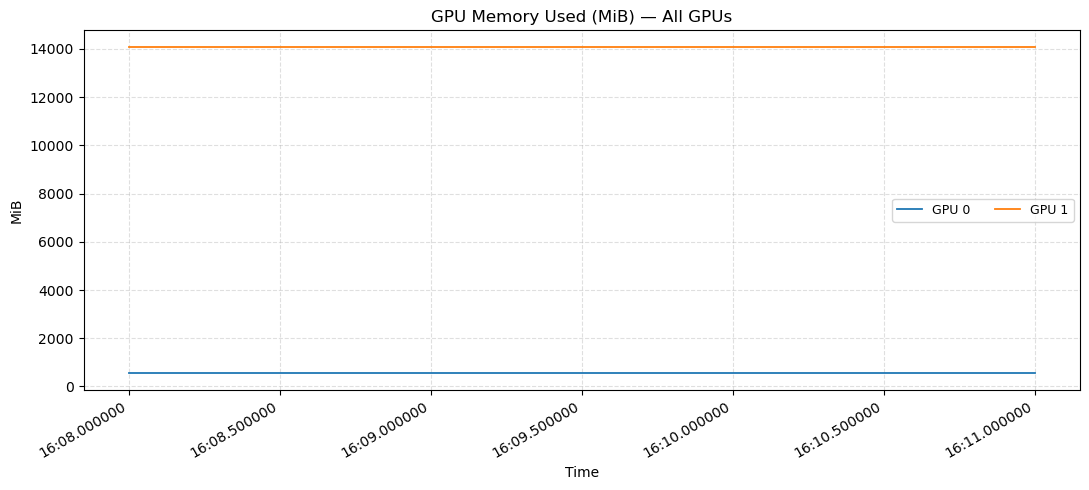

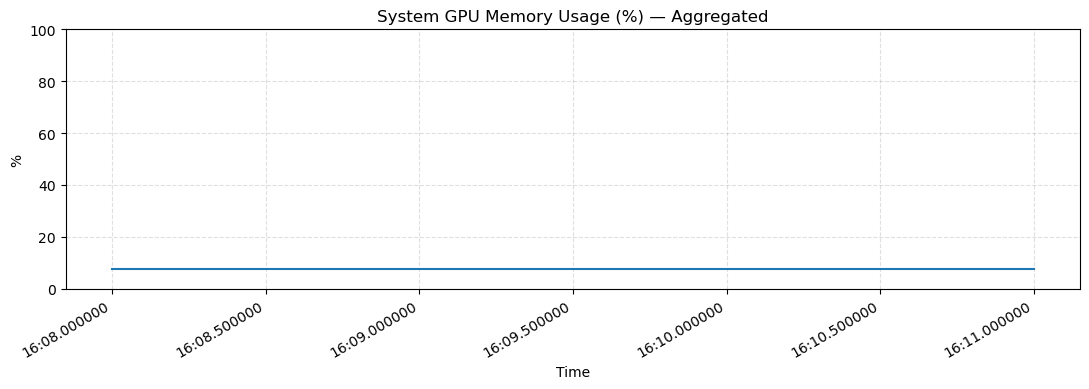

Saved plots to: gpumemplots


In [9]:

# os.outdir.mkdir(parents=True, exist_ok=True)

df = load_data(filename)
df = maybe_resample_and_smooth(df, resample=None, rolling=None)

plot_per_gpu(df, Path("gpumemplots"))
plot_combined(df, Path("gpumemplots"))

print(f"Saved plots to: gpumemplots")